In [25]:
import pandas as pd
import numpy as np

# -- Visualization --
import seaborn as sns
import matplotlib.pyplot as plt

# -- RDKit --
from rdkit import Chem
from rdkit.Chem import Draw, rdMolDescriptors, Lipinski, Descriptors, Crippen
from rdkit import DataStructs
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

pd.set_option('display.max_columns', None)

In [26]:
df = pd.read_csv(r'..\data\ptp1b_data.csv', delimiter=';')

In [27]:
df.head(2)

,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,Standard Value,Standard Units,pChEMBL Value,Data Validity Comment,Comment,Uo Units,Ligand Efficiency BEI,Ligand Efficiency LE,Ligand Efficiency LLE,Ligand Efficiency SEI,Potential Duplicate,Assay ChEMBL ID,Assay Description,Assay Type,BAO Format ID,BAO Label,Assay Organism,Assay Tissue ChEMBL ID,Assay Tissue Name,Assay Cell Type,Assay Subcellular Fraction,Assay Parameters,Assay Variant Accession,Assay Variant Mutation,Target ChEMBL ID,Target Name,Target Organism,Target Type,Document ChEMBL ID,Source ID,Source Description,Document Journal,Document Year,Cell ChEMBL ID,Properties,Action Type,Standard Text Value,Value
0,CHEMBL264833,NaN,NaN,611.71,1.0,4.25,50,N#Cc1ccc2[nH]c(C(Cc3ccc(C4CC(=O)NS4(=O)=O)cc3)...,IC50,'=',53.0,nM,7.28,NaN,NaN,UO_0000065,11.89,0.23,3.03,4.49,0,CHEMBL870503,Inhibition of PTP1B by pNPP assay,B,BAO_0000357,single protein format,Homo sapiens,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHEMBL335,Tyrosine-protein phosphatase non-receptor type 1,Homo sapiens,SINGLE PROTEIN,CHEMBL1138056,1,Scientific Literature,J Med Chem,2006,NaN,NaN,NaN,NaN,53.0
1,CHEMBL223067,NaN,NaN,292.29,0.0,4.21,8b,COc1ccc(-c2cc(=O)c3cc4ccoc4cc3o2)cc1,IC50,'=',68800.0,nM,4.16,NaN,NaN,UO_0000065,14.24,0.26,-0.05,7.92,0,CHEMBL918283,Inhibition of PTP1B in presence of 0.01% Trito...,B,BAO_0000357,single protein format,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHEMBL335,Tyrosine-protein phosphatase non-receptor type 1,Homo sapiens,SINGLE PROTEIN,CHEMBL1144560,1,Scientific Literature,Bioorg Med Chem,2007,NaN,NaN,NaN,NaN,68.8


In [28]:
df.isna().sum()

Molecule ChEMBL ID               0
Molecule Name                 4325
Molecule Max Phase            4725
Molecular Weight                 0
#RO5 Violations                 89
AlogP                           89
Compound Key                     0
Smiles                          29
Standard Type                    0
Standard Relation              220
Standard Value                 220
Standard Units                 212
pChEMBL Value                 1170
Data Validity Comment         4359
Comment                       4550
Uo Units                       213
Ligand Efficiency BEI         1200
Ligand Efficiency LE          1280
Ligand Efficiency LLE         1280
Ligand Efficiency SEI         1282
Potential Duplicate              0
Assay ChEMBL ID                  0
Assay Description                0
Assay Type                       0
BAO Format ID                    0
BAO Label                        0
Assay Organism                1414
Assay Tissue ChEMBL ID        4827
Assay Tissue Name   

In [29]:
df.columns

Index(['Molecule ChEMBL ID', 'Molecule Name', 'Molecule Max Phase',
       'Molecular Weight', '#RO5 Violations', 'AlogP', 'Compound Key',
       'Smiles', 'Standard Type', 'Standard Relation', 'Standard Value',
       'Standard Units', 'pChEMBL Value', 'Data Validity Comment', 'Comment',
       'Uo Units', 'Ligand Efficiency BEI', 'Ligand Efficiency LE',
       'Ligand Efficiency LLE', 'Ligand Efficiency SEI', 'Potential Duplicate',
       'Assay ChEMBL ID', 'Assay Description', 'Assay Type', 'BAO Format ID',
       'BAO Label', 'Assay Organism', 'Assay Tissue ChEMBL ID',
       'Assay Tissue Name', 'Assay Cell Type', 'Assay Subcellular Fraction',
       'Assay Parameters', 'Assay Variant Accession', 'Assay Variant Mutation',
       'Target ChEMBL ID', 'Target Name', 'Target Organism', 'Target Type',
       'Document ChEMBL ID', 'Source ID', 'Source Description',
       'Document Journal', 'Document Year', 'Cell ChEMBL ID', 'Properties',
       'Action Type', 'Standard Text Value', 'V

In [30]:
df = df[['Smiles', 'Standard Value']]
df = df[(~(df['Standard Value'].isna()) & ~(df['Smiles'].isna()))]
df = df[df['Standard Value']>0]

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4584 entries, 0 to 4830
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Smiles          4584 non-null   object 
 1   Standard Value  4584 non-null   float64
dtypes: float64(1), object(1)
memory usage: 107.4+ KB


In [32]:
df['Standard Value'].min()

np.float64(0.1)

In [33]:
def activity(value):
    if value <= 1000:
        return 1 # active
    elif value > 10000:
        return 0
    else:
        return np.nan
df['activity'] = df['Standard Value'].apply(activity)

In [34]:
df.dropna(subset=['activity'], inplace=True)

In [35]:
df.activity.value_counts()

activity
0.0    2002
1.0     993
Name: count, dtype: int64

In [36]:
def get_aromatic_proportion(mol):
    aromatic_atoms = sum([1 for atom in mol.GetAtoms() if atom.GetIsAromatic()])
    heavy_atoms = Descriptors.HeavyAtomCount(mol)
    return aromatic_atoms / heavy_atoms if heavy_atoms > 0 else 0

def calculate_descriptors_safe(smiles):
    """
    Calculates multiple molecular descriptors from a SMILES string.
    Returns a pandas Series so it can add multiple columns at once.
    Output schema is IDENTICAL to the original function.
    """
    morgan_gen = GetMorganGenerator(radius=2, fpSize=2048)
    try:
        # 1. Safely create and sanitize molecule
        mol = Chem.MolFromSmiles(smiles, sanitize=True)
        if mol is None:
            raise ValueError("Invalid SMILES")

        # 2. Remove explicit hydrogens (fixes H-without-neighbors warning)
        mol = Chem.RemoveHs(mol)

        # 3. Calculate descriptors (same as before)
        return pd.Series({
            'tpsa': rdMolDescriptors.CalcTPSA(mol),
            'mw':   Descriptors.MolWt(mol),
            'hbd':  Descriptors.NumHDonors(mol),
            'hba':  Descriptors.NumHAcceptors(mol),
            'rot':  Descriptors.NumRotatableBonds(mol),
            'logp': Crippen.MolLogP(mol),
            'mr':   Crippen.MolMR(mol),
            'hac':  Lipinski.HeavyAtomCount(mol),
            'fp':   morgan_gen.GetFingerprint(mol),  # 🔥 NO deprecation warning
            'aromatic_proportion': get_aromatic_proportion(mol)
        })

    except Exception:
        # 4. Fail safely (same NaN structure as original)
        return pd.Series({
            'tpsa': np.nan,
            'mw': np.nan,
            'hbd': np.nan,
            'hba': np.nan,
            'rot': np.nan,
            'logp': np.nan,
            'mr': np.nan,
            'hac': np.nan,
            'fp': np.nan,
            'aromatic_proportion': np.nan
        })

# Apply the function (Creating all columns in one go)
# This returns a new DataFrame with the descriptor columns
descriptor_cols = df['Smiles'].apply(calculate_descriptors_safe)

# Join these new columns back to your original DataFrame
df = pd.concat([df, descriptor_cols], axis=1)

# Check for failures (just checking one column is enough since they all fail together)
print(f"Failed rows: {df['tpsa'].isna().sum()}")

Failed rows: 0


In [37]:
df.head(2)

,Smiles,Standard Value,activity,tpsa,mw,hbd,hba,rot,logp,mr,hac,fp,aromatic_proportion
0,N#Cc1ccc2[nH]c(C(Cc3ccc(C4CC(=O)NS4(=O)=O)cc3)...,53.0,1.0,161.88,611.705,3,7,8,4.25468,160.3157,43,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.627907
1,COc1ccc(-c2cc(=O)c3cc4ccoc4cc3o2)cc1,68800.0,0.0,52.58,292.290,0,4,2,4.21480,84.2440,22,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.863636


In [38]:
def to_array(fp):
    arr = np.zeros(fp.GetNumBits(), dtype=np.uint8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr
fp_array = df['fp'].apply(to_array)

df['fp'] = fp_array

In [39]:
df.fp

0       [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
1       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
2       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
5       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
6       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
                              ...                        
4826    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
4827    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
4828    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
4829    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
4830    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
Name: fp, Length: 2995, dtype: object

In [40]:
df.columns

Index(['Smiles', 'Standard Value', 'activity', 'tpsa', 'mw', 'hbd', 'hba',
       'rot', 'logp', 'mr', 'hac', 'fp', 'aromatic_proportion'],
      dtype='object')

In [41]:
cols = ['tpsa', 'mw', 'hbd', 'hba', 'rot', 'logp', 'mr', 'hac', 'aromatic_proportion']

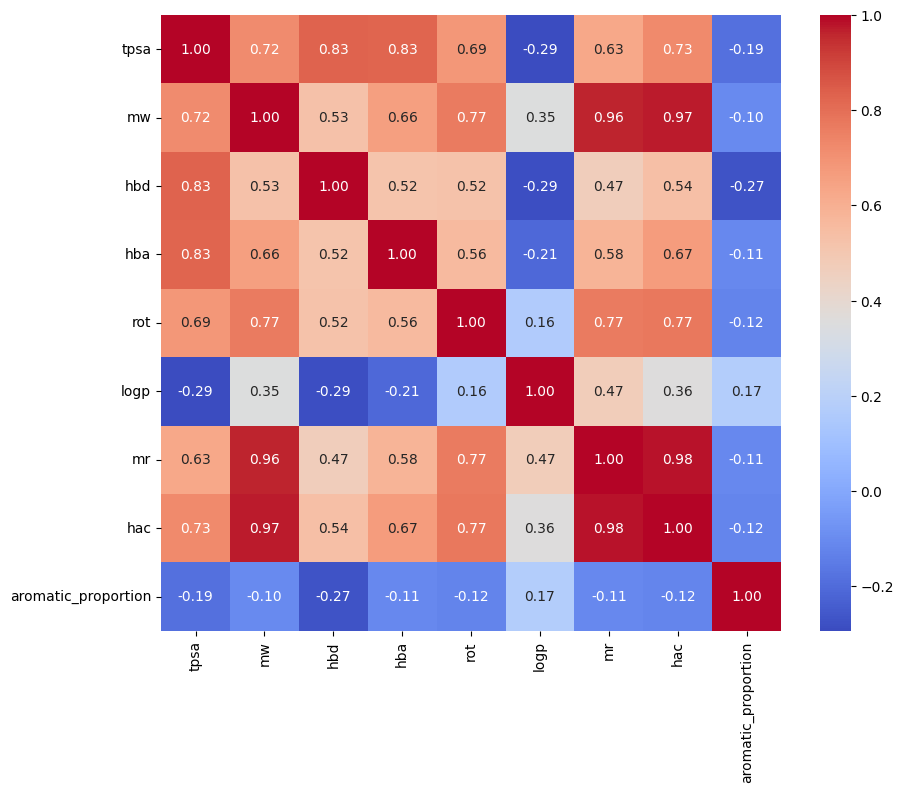

In [42]:
corr_matrix = df[cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [43]:
df.columns

Index(['Smiles', 'Standard Value', 'activity', 'tpsa', 'mw', 'hbd', 'hba',
       'rot', 'logp', 'mr', 'hac', 'fp', 'aromatic_proportion'],
      dtype='object')

In [44]:
scalor = ['mw', 'hbd', 'hba', 'rot', 'logp', 'aromatic_proportion']
# X = np.hstack([df[scalor], np.stack(df['fp'])])
X = np.stack(df['fp'])
# X = df['fp']
y = df['activity']

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [46]:
# Initialize Random Forest Regressor
model = SVC()

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
# mae = mean_absolute_error(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print(classification_report(y_test, y_pred))
print(f'CM Score: \n{cm}')


              precision    recall  f1-score   support

         0.0       0.92      0.95      0.94       400
         1.0       0.90      0.84      0.87       199

    accuracy                           0.91       599
   macro avg       0.91      0.90      0.90       599
weighted avg       0.91      0.91      0.91       599

CM Score: 
[[381  19]
 [ 32 167]]


In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error, r2_score, classification_report, confusion_matrix

# Initialize Random Forest Regressor
model = RandomForestClassifier()

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
# mae = mean_absolute_error(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print(classification_report(y_test, y_pred))
print(f'CM Score: \n{cm}')


              precision    recall  f1-score   support

         0.0       0.94      0.94      0.94       400
         1.0       0.87      0.87      0.87       199

    accuracy                           0.91       599
   macro avg       0.90      0.90      0.90       599
weighted avg       0.91      0.91      0.91       599

CM Score: 
[[375  25]
 [ 26 173]]


In [48]:
from xgboost import XGBClassifier
from sklearn.metrics import mean_absolute_error, r2_score, classification_report, confusion_matrix

# Initialize Random Forest Regressor
model = XGBClassifier()

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
# mae = mean_absolute_error(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print(classification_report(y_test, y_pred))
print(f'CM Score: \n{cm}')


              precision    recall  f1-score   support

         0.0       0.95      0.93      0.94       400
         1.0       0.87      0.89      0.88       199

    accuracy                           0.92       599
   macro avg       0.91      0.91      0.91       599
weighted avg       0.92      0.92      0.92       599

CM Score: 
[[373  27]
 [ 21 178]]


In [49]:
from lightgbm import LGBMClassifier
from sklearn.metrics import mean_absolute_error, r2_score, classification_report, confusion_matrix

# Initialize Random Forest Regressor
model = LGBMClassifier()

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
# mae = mean_absolute_error(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print(classification_report(y_test, y_pred))
print(f'CM Score: \n{cm}')


[LightGBM] [Info] Number of positive: 794, number of negative: 1602
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013128 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2026
[LightGBM] [Info] Number of data points in the train set: 2396, number of used features: 1013
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.331386 -> initscore=-0.701925
[LightGBM] [Info] Start training from score -0.701925
              precision    recall  f1-score   support

         0.0       0.94      0.94      0.94       400
         1.0       0.87      0.87      0.87       199

    accuracy                           0.91       599
   macro avg       0.90      0.90      0.90       599
weighted avg       0.91      0.91      0.91       599

CM Score: 
[[375  25]
 [ 26 173]]


c:\Users\yashd\OneDrive\Desktop\GenAI\1. Jupyter\Projects\pd_ds\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
